# k-최근접 이웃 회귀

회귀는 클래스로 분류하는 것이 아니라 **임의의 어떤 숫자를 예측하는 문제 입니다.**

k-최근접 이웃 분류는 가까운 이웃들의 클래스를 확인 후 다수의 클래스를 새로운 샘플의 클래스로 예측합니다.

k-최근접 이웃 회귀는 가까운 이웃들의 평균으로 타겟을 정합니다.

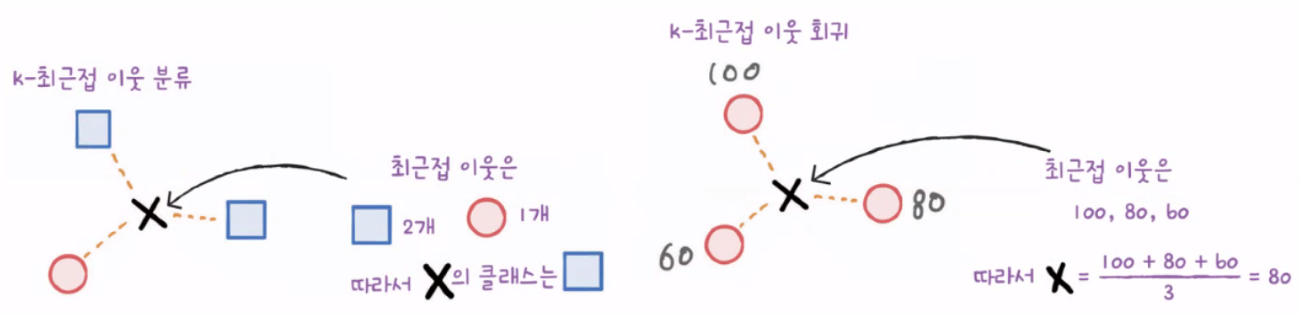

---

## 데이터 준비

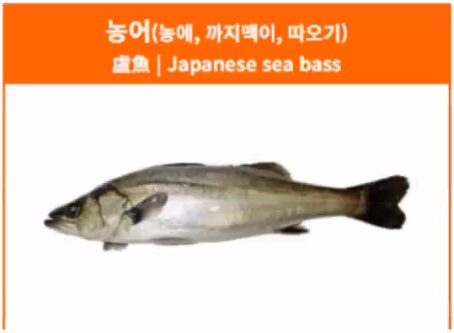

농어 길이를 알고 있을 때 무게를 예측하기 위한 데이터


In [1]:
import numpy as np

In [2]:
# 56개의 데이터 준비
# 길이
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
# 무게
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

### 산점도 그리기


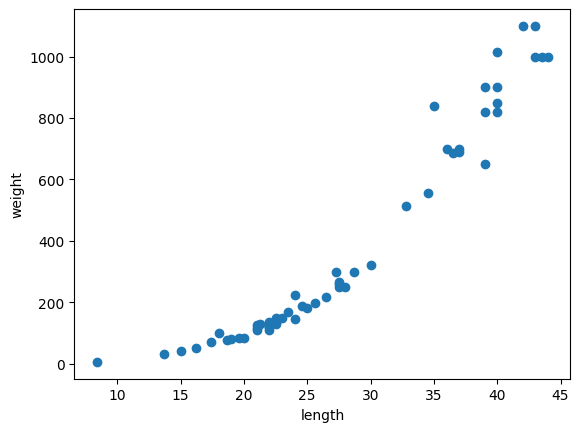

In [3]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

---

### 훈련 세트, 테스트 세트 준비

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

In [6]:
print(train_input.shape, test_input.shape)

(42,) (14,)


 ---
넘파이의 reshape()로 1차원을 2차원으로 바꾸기 예제

In [7]:
test_array = np.array([1, 2, 3, 4])
print(test_array.shape)

(4,)


In [8]:
test_array = test_array.reshape(2, 2)
print(test_array)
print(test_array.shape)

[[1 2]
 [3 4]]
(2, 2)


 ---
### train_input, test_input 입력 데이터를 1차원 배열에서 2차원 배열로 바꾸기

- 이유: 사이킷런(sklearn) 같은 머신러닝 라이브러리에서 입력 데이터 X를 "(샘플 수, 특성 수)" 형태의 2차원 배열로 요구합니다.

    예) fit(X, y): 모델 학습 단계, predict(X): 예측 단계, transform(X) / fit_transform(X): 데이터 전처리 단계

- 특성이 1개인 경우, 입력 데이터가 1차원 배열로 만들어질 수 있으므로 이를 2차원 배열로 변환해야 합니다.

- 이때 넘파이의 reshape(-1, 1)을 사용하여 (샘플 수, 1) 형태의 2차원 배열로 변환합니다..

In [9]:
print(test_input)

[ 8.4 18.  27.5 21.3 22.5 40.  30.  24.6 39.  21.  43.5 16.2 28.  27.3]


In [10]:
test_input = test_input.reshape(-1, 1)
print(test_input)

[[ 8.4]
 [18. ]
 [27.5]
 [21.3]
 [22.5]
 [40. ]
 [30. ]
 [24.6]
 [39. ]
 [21. ]
 [43.5]
 [16.2]
 [28. ]
 [27.3]]


In [11]:
train_input = train_input.reshape(-1, 1)

print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


 ---
모델 생성과 훈련

In [12]:
from sklearn.neighbors import KNeighborsRegressor

In [13]:
knr = KNeighborsRegressor()

knr.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
knr.score(test_input, test_target)

0.992809406101064

 ---
## 결정 계수 ($R^2$) - KNeighborsRegressor모델에서의 score() 반환값

결정계수(Coefficient of Determination, $R^2$)는 회귀 모델이 실제 값의 변동을 얼마나 잘 설명하는지를 나타내는 지표입니다.

---

1. 결정 계수를 이해하기 위한 예
    - 평소 시험 평균이 80점인 학생의 중간고사 점수를 예측하려고 합니다.

    - 모델이 없을 때: "평균은 받겠지" (가장 단순한 기준, 평균 예측)

    - 공부 시간을 적용한 모델이 있을 때: "어제 10시간 공부했으니 90점일 것"이라고 예측
2. 결정계수 공식 의미
    - $R^2 = 1 - \frac{\sum{(target-predict)^2}}{\sum{(target-mean)^2}}$

    - 분모: 평균으로만 예측했을 때의 전체 제곱 오차

    - 분자: 모델이 에측인 값의 전체 제곱 오차

    만약 결정계수가 0.9라는 의미는 중간고사 점수가 평균에서 왜 멀어지는지(변동성) 이유를 모델이 90% 설명하고 있다는 의미입니다. 만약 결정계수가 0이라면 중간 고사 성적은 "평균은 받겠지"라고 대답한 것과 같습니다. 모델이 평균 예측보다 전혀 나아지지 않았음을 의미합니다.

---

결정계수 $R^2$는 이렇게 정의됩니다.

$R^2 = 1 - \frac{SSE}{SST}$

1. $SSE = \sum{(y_i - \hat{y_i})^2}$ : 오차제곱합(Residual Sum of Squares)

    타깃과 예측 값 차이의 제곱 합 (모델이 맞히지 못한 오차)

2. $SST = \sum{(y_i - \bar{y})^2}$ : 전체제곱합(Total Sum of Squares)

    타깃과 평균값 차이의 제곱 합

3. $y_i$ : 실제 값

4. $\hat{y_i}$ : 에측 값

5. $\bar{y}$ : 실제 값 평균

---

결정 계수 값에 따른 해석
| **$R^2$ 값** | **의미** |
| :--- | :--- |
| **1.0** | 예측이 완벽합니다 |
| **0.9** | 매우 잘 예측합니다 |
| **0.5** | 절반 정도만 설명합니다 |
| **0.0** | 예측값이 전부 평균값과 동일합니다 |
| **음수** | 평균보다도 못한 예측입니다 |


 ---
$R^2$(결정계수)는 평균값만 예측하는 모델을 기준으로, 현재 모델의 예측 성능이 얼마나 개선되었는지를 나타내는 상대적 지표입니다. 따라서 실제 예측 오차의 크기나 단위를 직접적으로 알 수 없습니다.

반면 MAE, RMS는 예측값과 실제값의 차이를 원래 데이터의 단위 그대로 표현하는 절대적 오차 지표입니다.

따라서 회귀 모델 평가는 $R^2$와 함께 MAE, RMSE와 같은 오차 기반 지표를 함께 확인하는 것이 일반적입니다.

예) 상황 A: $R^2 = 0.9$ (오차 MAE = 10g) $\rarr$ 매우 훌륭합니다.

- MAE = 10g는 예측이 평균적으로 10g 정도 틀린다는 의미

예) 상황 B: $R^2 = 0.9$ (오차 MAE = 10kg) $\rarr$ 설명력은 높지만, 오차 단위가 너무 커서 실제 서비스에선 못 쓸 수도 있습니다.

- MAR = 10kg는 예측이 평균적으로 10kg 정도 틀린다는 의미

 ---

### 평균 절댓값 오차(MAE: Mean Absolute Error)

공식:

$MAE = \frac{1}{n}\sum^n_{i=1}{|y_i - \hat{y}_i|}$

| **기호** | **설명** |
| :--- | :--- |
| $y_i$ | 실제값 (정답값, target) |
| $\hat{y}_i$ | 예측값 (prediction) |
| $n$ | 샘플 개수 |

각 데이터의 "예측값"과 "실제값"의 차이를 절댓값으로 바꿔서 그 차이의 평균을 구한 값입니다.

---

### MSE (평균제곱오차, Mean Squared Error)

$MSE = \frac{1}{n}\sum^n_{i=1}{(y_i - \hat{y}_i)^2}$

- 각 예측값과 실제값의 차이를 제곱하여 평균낸 값입니다.
- 오차를 제곱했기 때문에 큰 예측 실수를 한 경우 모델 평가에 크게 반영됩니다.
- 일부 데이터에서 큰 오차가 발생할 경우 값이 크게 증가합니다.

---

### RMSE (제곱근 평균제곱오차, Root Mean Squared Error)

$RMSE = \sqrt{\frac{1}{n}\sum^n_{i=1}{(y_i - \hat{y}_i)^2}}$

MSE에 제곱근을 취한 값입니다.

오차의 단위가 타깃 변수와 동일하여 해석이 직관적입니다.

큰 오차에 민감한 특성은 유지하면서도 실제 오차 크기를 이해하기 쉽습니다.

평균적으로 얼마나 틀렸는지를 실제 단위 기준으로 표현할 수 있습니다.

---

In [15]:
from sklearn.metrics import mean_absolute_error

In [16]:
test_prediction = knr.predict(test_input)

mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


### 모델의 예측이 실제값과 평균적으로 약 19g 정도 차이가 난다는 의미입니다.

---

In [17]:
from sklearn.metrics import mean_squared_error

test_prediction = knr.predict(test_input)

mse = mean_squared_error(test_target, test_prediction)
print(mse)

721.7385714285714


일부 데이터에서 큰 오차가 발생할 경우 값이 크게 증가합니다.

---

In [18]:
from sklearn.metrics import root_mean_squared_error

test_prediction = knr.predict(test_input)

rmse = root_mean_squared_error(test_target, test_prediction)
print(rmse)

26.865192562655704


테스트 데이터에서 모델의 예측값은 평균적으로 실제값과 평균적으로 약 26.9 정도 차이가 난다는 의미입니다.

이 값은 큰 오차까지 고려했을 때의 평균적인 예측 오차 크기입니다.

---

| **지표** | **값** | **해석** | **특징** |
| :--- | :--- | :--- | :--- |
| MAE | 19.16 | 평균적인 오차 크기 | 이상치에 덜 민감 |
| MSE | 721.74 | 오차를 제곱한 평균값 | 큰 오차의 영향을 크게 받음 |
| RMSE | 26.87 | 평균 오차의 크기 | 실제 단위로 해석 가능, 큰 오차에 민감 |

결론적으로,

모델의 예측이 실제값과 평균적으로 약 19~27 정도 오차를 가진다는 의미이며,

MSE가 상대적으로 큰 경우는 일부 데이터에서 큰 오차가 발생했을 가능성, 또는 타깃 값의 범위(스케일)가 큰 특성으로 인해 오차 제곱 값이 크게 반영되었을 수 있습니다.

---

## 과대적합 vs 과소적합

In [19]:
print(knr.score(train_input, train_target))

0.9698823289099254


In [20]:
print(knr.score(test_input, test_target))

0.992809406101064


### K-최근접 이웃(KNN) 회귀 모델의 성능 최적화

1. 모델 진단: 과소적합(Underfitting) vs 과대적합(Overfitting)

    과소적합 (Underfitting)
    - 현상: 훈련 세트 점수 < 테스트 세트 점수 (또는 두 점수 모두 지나치게 낮음)

    - 원인: 모델이 너무 단순하여 데이터의 내재된 패턴을 충분히 학습하지 못함

    - 해결: 모델을 더 복잡하게 만들어 훈련 데이터의 특징을 세밀하게 반영함

    과대적합 (Overfitting)
    - 현상: 훈련 세트 점수 > 테스트 세트 점수

    - 원인: 모델이 훈련 데이터에만 지나치게 최적화되어, 새로운 데이터(테스트 세트)에 대한 일반화 능력이 떨어짐

    - 해결: 모델을 더 단순하게 만들어 보편적인 패턴을 학습하게 함

        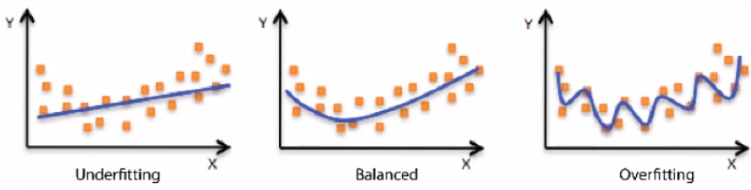
        
        출처) https://docs.aws.amazon.com/machine-learning/latest/dg/model-fit-underfitting-vs-overfitting.html
        - Underfitting (좌측): 모델이 너무 단순하여 데이터를 충분히 구분하지 못하는 상태입니다. KNN에서는 $k$값이 너무 클 때 발생합니다.
        - Balanced (중앙): 훈련 데이터의 일반적인 패턴을 잘 학습하여 새로운 데이터도 잘 맞출 수 있는 상태입니다. 훈련 세트와 테스트 세트의 점수가 모두 높고 균형을 이룹니다.
        - Overfitting (우측): 모델이 너무 복잡하여 훈련 데이터의 노이즈까지 다 외워버린 상태입니다. KNN에서는 $k$값이 너무 작을 때 발생하며, 훈련 점수는 매우 높지만 테스트 점수는 낮게 나옵니다.

2. KNN 모델의 복잡도 조절: $k$ 값의 역할

    K-최근접 이웃 알고리즘에서 이웃의 개수($k$)는 모델의 복잡도를 결정하는 핵시 하이퍼파라미터입니다.

    | **조절 방향** | **모델의 복잡도** | **학습 결과 및 특징** | **비고** |
    | :--- | :--- | :--- | :--- |
    | **k를 늘릴 때** | 단순해짐 | 데이터의 전반적인 경향(평균)에 가까운 값만 참고함 | **과소적합(Underfitting) 위험** |
    | **k를 줄일 때** | 복잡해짐 | 훈련 데이터의 국지적인 패턴과 타겟을 매우 밀접하게 참고함 | **과대적합(Overfitting) 위험** |


3. 우리 예제의 해결 방안

- 현재 테스트 세트 점수가 더 높은 과소적합 상태이므로, 모델을 더 복잡하게 개선해야 합니다.
    - 진단: 사이킷런 기본값 $k = 5$는 현재 데이터의 패턴을 파악하기에 너무 단순함
    - 조치: 이웃의 개수를 $k = 3$으로 감소시켜 모델의 복잡도를 높임
    - 기대 효과: 훈련 세트에 더 잘 맞게 되어 훈련 세트 점수는 상승하고, 두 세트 간의 점수 균형이 맞춰짐

In [21]:
knr.set_params(n_neighbors=3)

knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))

0.9804899950518966


In [22]:
print(knr.score(test_input, test_target))

0.9746459963987609


훈련 세트와 테스트 세트의 점수 차이가 줄어들며 과소적합이 해결되었습니다.

---

예측

In [23]:
print(knr.predict(np.array([[10]])))

[47.33333333]


In [24]:
print(knr.predict(np.array([[20]])))

[95.]


In [25]:
print(knr.predict(np.array([[10], [20]])))

[47.33333333 95.        ]
